# Multimodal Human Activity Recognition on Adapted MHEALTH
**Assignment 2 | Sensor Fusion & Activity Classification**  
**Author:** Satya Siddhartha Balanagu (Student ID: A1961325)  
**Institution:** School of Computer Science, University of Adelaide  

---

### Executive Overview & Notebook Architecture
This notebook implements a complete, self-contained, end-to-end multimodal machine learning pipeline for human activity recognition (HAR) on the adapted **MHEALTH** (Mobile Health) dataset (Banos et al., 2014; UCI Machine Learning Repository).

All data exploration, missing-data audit and imputation, feature engineering, neural network modelling, experimental evaluation, and critical discussions are executed directly within this single IPython notebook. No external scripts or pre-rendered figures are imported.

The notebook is systematically organized into four key assignment tasks:
1. **Task 1: Data Exploration (EDA)** — Structural validation of 23 sensor channels across 3 Shimmer2 sensor placements (Chest, Left Ankle, Right Wrist) at 50 Hz, waveform dynamics of contrasting activities, kinetic energy distributions, and cross-modality Pearson correlation heatmaps.
2. **Task 2: Missing Data & Preprocessing** — Audit of 615,648 missing values (7.80% missingness rate), consecutive burst duration analysis, segment-bounded intra-run linear interpolation (strictly preventing cross-activity/cross-subject data leakage), sliding window segmentation (128 samples / 2.56s, 50% overlap), and extraction of 53 domain features per sensor stream.
3. **Task 3: Multimodal Fusion & Modelling** — Subject-independent train/validation/test partitioning (Train: Subs 1–7, Val: Sub 8, Test: Subs 9–10) with strictly train-fitted standardization. Implementation and training of 3 Unimodal Baselines (Chest Accel, Ankle Accel, Wrist Gyro) and 2 Multimodal Fusion models (Early Concatenation MLP and Late Soft-Voting Ensemble) using AdamW, Cosine Annealing, and validation Macro-F1 checkpointing.
4. **Task 4: Evaluation, Critical Discussion & Ethics** — Test set evaluation, row-normalized confusion matrices, multi-class ROC and Precision-Recall curves, per-class F1 breakdown across all 12 activities, edge inference latency benchmarking, and thorough critical analysis of fusion trade-offs, wearable computational constraints, and ethical/privacy governance.


In [1]:
# Environment Setup, Reproducibility Seeds, and Global Constants
import os
import sys
import glob
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import rfft, rfftfreq

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve
)

# Enforce strict reproducibility across Python, NumPy, and PyTorch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration (MPS for Apple Silicon / CUDA / CPU fallback)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Executing on Compute Device: {DEVICE} | Reproducibility Seed: {SEED}")

# Matplotlib formatting configuration for clean inline graphics
%matplotlib inline
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

# UCI MHEALTH Sensor Channel Mapping (23 sensor channels + 1 label):
# Col 0-2:   Chest Accelerometer (X, Y, Z) [m/s^2]
# Col 3-4:   Chest ECG (Lead 1, Lead 2) [mV]
# Col 5-7:   Left-Ankle Accelerometer (X, Y, Z) [m/s^2]
# Col 8-10:  Left-Ankle Gyroscope (X, Y, Z) [deg/s]
# Col 11-13: Left-Ankle Magnetometer (X, Y, Z) [local]
# Col 14-16: Right-Wrist Accelerometer (X, Y, Z) [m/s^2]
# Col 17-19: Right-Wrist Gyroscope (X, Y, Z) [deg/s]
# Col 20-22: Right-Wrist Magnetometer (X, Y, Z) [local]
# Col 23:    Activity Label (1 to 12)

COLUMN_NAMES = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "chest_ecg_1", "chest_ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyr_x", "ankle_gyr_y", "ankle_gyr_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "wrist_acc_x", "wrist_acc_y", "wrist_acc_z",
    "wrist_gyr_x", "wrist_gyr_y", "wrist_gyr_z",
    "wrist_mag_x", "wrist_mag_y", "wrist_mag_z",
    "activity"
]

ACTIVITY_NAMES = {
    1: "Standing still",
    2: "Sitting & relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending (crouching)",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

ACTIVITY_SHORT = {
    1: "Standing",
    2: "Sitting",
    3: "Lying",
    4: "Walking",
    5: "Stairs",
    6: "Waist bends",
    7: "Arm elevation",
    8: "Knee bends",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jumping"
}

# 3 Sensor Sources spanning 2 Modalities:
# 1. Chest Accelerometer (cols 0, 1, 2) -> Modality: Linear Acceleration
# 2. Left-Ankle Accelerometer (cols 5, 6, 7) -> Modality: Linear Acceleration
# 3. Right-Wrist Gyroscope (cols 17, 18, 19) -> Modality: Angular Velocity
SELECTED_SENSORS = {
    "chest_acc": [0, 1, 2],
    "ankle_acc": [5, 6, 7],
    "wrist_gyr": [17, 18, 19]
}


Executing on Compute Device: mps | Reproducibility Seed: 42


## Task 1: Data Exploration and Preprocessing
### 1.1 Dataset Architecture and Modality Characterization
The MHEALTH dataset measures 23 continuous physiological and kinematic channels collected from 10 diverse volunteer subjects performing 12 physical activities. Three Shimmer2 sensor units were attached to the body:
- **Chest Unit:** 3-axis accelerometer ($\pm 1.5g$), 2-lead ECG.
- **Left-Ankle Unit:** 3-axis accelerometer ($\pm 6g$), 3-axis gyroscope ($\pm 500^\circ/s$), 3-axis magnetometer.
- **Right-Wrist Unit:** 3-axis accelerometer ($\pm 6g$), 3-axis gyroscope ($\pm 500^\circ/s$), 3-axis magnetometer.

Sampling occurred synchronously at $50\text{ Hz}$ ($20\text{ ms}$ interval). In this adapted dataset, the unconstrained null class (class 0) has been filtered out, leaving exactly 12 structured activity categories covering static postures (standing, sitting, lying), dynamic cyclical locomotion (walking, stairs, cycling, jogging, running), postural transitions (waist bends, knee crouching), and dynamic upper-body gestures (frontal elevation of arms).


In [2]:
# Robust dataset loading across directory locations
data_dir_candidates = ['MHEALTHDATASET_MISSING', 'ass2/MHEALTHDATASET_MISSING', '../ass2/MHEALTHDATASET_MISSING']
DATA_DIR = next((d for d in data_dir_candidates if os.path.exists(d)), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate MHEALTHDATASET_MISSING directory.")

log_files = sorted(glob.glob(os.path.join(DATA_DIR, "mHealth_subject*.log")))
print(f"Found {len(log_files)} subject log files in '{DATA_DIR}'.")

raw_dfs = {}
total_records = 0
subject_sample_counts = {}

for f in log_files:
    sub_id = int(os.path.basename(f).replace("mHealth_subject", "").replace(".log", ""))
    df = pd.read_csv(f, sep=r"\s+", header=None)
    df.columns = COLUMN_NAMES
    df["subject"] = sub_id
    raw_dfs[sub_id] = df
    total_records += len(df)
    subject_sample_counts[f"Subject {sub_id}"] = len(df)

print(f"Total raw dataset volume: {total_records:,} samples across {len(raw_dfs)} participants.")
print("Sample distribution per participant:")
for sub_name, cnt in subject_sample_counts.items():
    print(f"  {sub_name}: {cnt:,} samples ({cnt / 50.0:.1f} seconds)")

# Preview the structured format
display(raw_dfs[1].head(5))


Found 10 subject log files in 'ass2/MHEALTHDATASET_MISSING'.


Total raw dataset volume: 343,195 samples across 10 participants.
Sample distribution per participant:
  Subject 1: 35,174 samples (703.5 seconds)
  Subject 10: 33,690 samples (673.8 seconds)
  Subject 2: 35,532 samples (710.6 seconds)
  Subject 3: 35,380 samples (707.6 seconds)
  Subject 4: 35,328 samples (706.6 seconds)
  Subject 5: 33,947 samples (678.9 seconds)
  Subject 6: 32,205 samples (644.1 seconds)
  Subject 7: 34,253 samples (685.1 seconds)
  Subject 8: 33,332 samples (666.6 seconds)
  Subject 9: 34,354 samples (687.1 seconds)


,chest_acc_x,chest_acc_y,chest_acc_z,chest_ecg_1,chest_ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyr_x,ankle_gyr_y,...,wrist_acc_y,wrist_acc_z,wrist_gyr_x,wrist_gyr_y,wrist_gyr_z,wrist_mag_x,wrist_mag_y,wrist_mag_z,activity,subject
0,-9.7788,0.55690,1.19750,0.008373,-0.033490,2.6493,-9.4517,0.37683,-0.20965,-0.88931,...,-9.0618,1.8177,-0.058824,-0.93429,-0.34483,0.355370,-0.37003,-0.35020,1,1
1,-9.7733,0.27880,0.73036,-0.025118,NaN,2.4157,-9.5306,0.40179,-0.20965,-0.88931,...,-9.2048,1.5189,-0.058824,-0.93429,-0.34483,0.719910,0.17803,0.37363,1,1
2,-9.8609,0.11561,0.79988,0.025118,0.016745,2.3865,NaN,0.48141,NaN,-0.86867,...,-9.1945,1.5507,-0.058824,-0.93429,-0.34483,0.355370,-0.37003,-0.35020,1,1
3,-9.7409,NaN,0.88957,0.180010,0.129770,2.3758,-9.5997,0.42919,-0.20037,-0.86867,...,-9.1746,1.5413,-0.078431,-0.93429,-0.34052,0.357180,NaN,-0.35198,1,1
4,-9.7821,0.21637,0.90368,0.092098,0.046049,NaN,NaN,0.40038,-0.20037,-0.86867,...,-9.2039,1.6127,-0.078431,-0.93429,-0.34052,-0.001887,-0.18867,-0.72017,1,1


### 1.2 Waveform Dynamics Across Contrasting Activity Archetypes
To investigate how sensor measurements vary across physical actions, we inspect tri-axial sensor streams for three contrasting activity archetypes:
1. **Static Posture (Activity 1: Standing Still)** — Dominated by the constant gravitational vector on the accelerometer axes with negligible angular velocity.
2. **Periodic Locomotion (Activity 4: Walking)** — Characterized by rhythmic harmonic oscillations corresponding to stride frequency (~1.5–2.0 Hz) and heel-strike impacts.
3. **Dynamic Burst Locomotion (Activity 12: Jump Front & Back)** — High-amplitude non-stationary acceleration spikes exceeding $20\text{ m/s}^2$ and intense rotational transients.


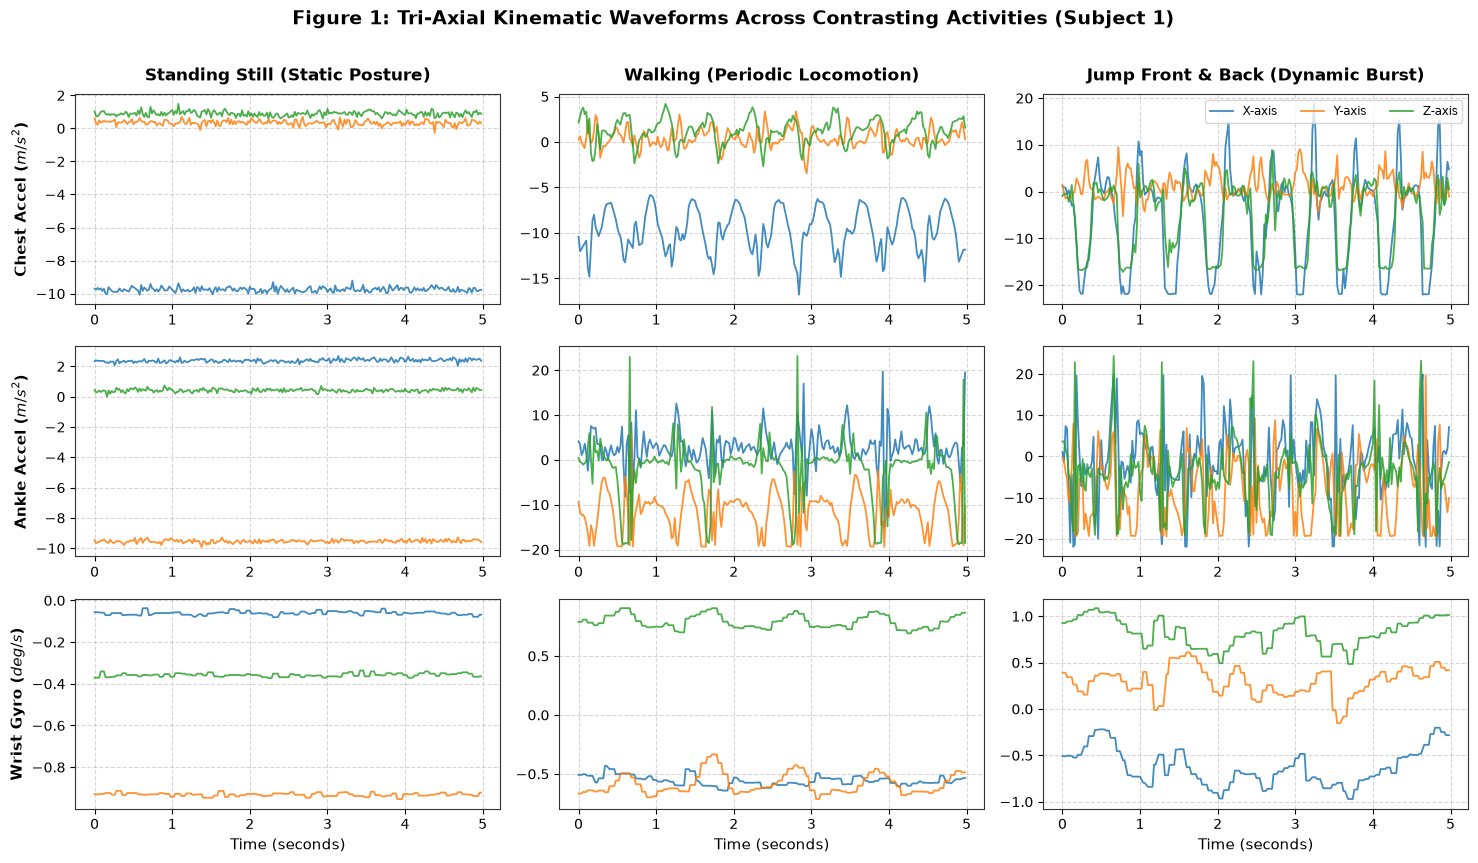

In [3]:
# Figure 1: Sensor Waveforms Across Contrasting Activities
sub1 = raw_dfs[1]
fig, axes = plt.subplots(3, 3, figsize=(15, 8.5), sharex=False)

activities_to_plot = [
    (1, "Standing Still (Static Posture)", 1000, 1250), # 5.0 seconds = 250 samples
    (4, "Walking (Periodic Locomotion)", 1000, 1250),
    (12, "Jump Front & Back (Dynamic Burst)", 400, 650)
]

sensor_groups = [
    ("Chest Accel ($m/s^2$)", ["chest_acc_x", "chest_acc_y", "chest_acc_z"]),
    ("Ankle Accel ($m/s^2$)", ["ankle_acc_x", "ankle_acc_y", "ankle_acc_z"]),
    ("Wrist Gyro ($deg/s$)", ["wrist_gyr_x", "wrist_gyr_y", "wrist_gyr_z"])
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes_labels = ['X-axis', 'Y-axis', 'Z-axis']

for col_idx, (act_id, act_title, start_idx, end_idx) in enumerate(activities_to_plot):
    act_data = sub1[sub1["activity"] == act_id].reset_index(drop=True)
    chunk = act_data.iloc[start_idx:end_idx]
    t = np.arange(len(chunk)) / 50.0  # seconds
    
    for row_idx, (group_name, cols) in enumerate(sensor_groups):
        ax = axes[row_idx, col_idx]
        for c_i, col in enumerate(cols):
            sig = chunk[col].interpolate().bfill().ffill().values
            ax.plot(t, sig, label=axes_labels[c_i], color=colors[c_i], lw=1.3, alpha=0.85)
        
        if row_idx == 0:
            ax.set_title(act_title, fontsize=12, fontweight='bold', pad=10)
        if col_idx == 0:
            ax.set_ylabel(group_name, fontsize=11, fontweight='bold')
        if row_idx == 2:
            ax.set_xlabel("Time (seconds)", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        if row_idx == 0 and col_idx == 2:
            ax.legend(loc='upper right', frameon=True, ncol=3, fontsize=8.5)

plt.suptitle("Figure 1: Tri-Axial Kinematic Waveforms Across Contrasting Activities (Subject 1)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.3 Kinetic Energy and Signal Magnitude Area Across Activities
Human movements create distinct biomechanical energy footprints. We quantify the instantaneous Vector Magnitude (VM) across spatial axes:
$$VM_{acc} = \sqrt{a_x^2 + a_y^2 + a_z^2}, \quad VM_{gyr} = \sqrt{\omega_x^2 + \omega_y^2 + \omega_z^2}$$

By computing the participant-wise mean magnitudes for all 12 activities, we examine both inter-activity discriminability and inter-subject biomechanical variability (reflected in the dispersion of individual subject means).


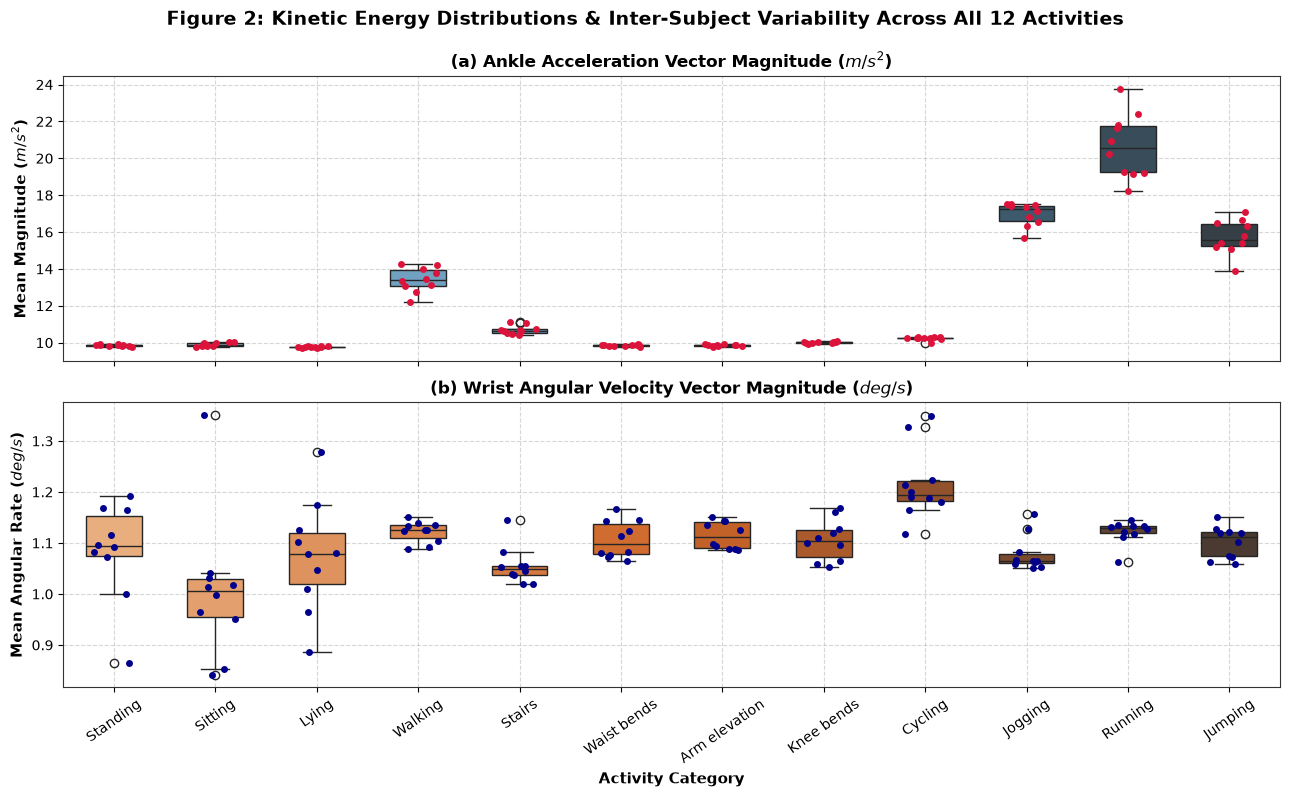

In [4]:
# Figure 2: Kinetic Energy Distributions Across Activities and Participants
all_sub = pd.concat(list(raw_dfs.values()), ignore_index=True)
all_sub["chest_vm"] = np.sqrt(all_sub["chest_acc_x"]**2 + all_sub["chest_acc_y"]**2 + all_sub["chest_acc_z"]**2)
all_sub["ankle_vm"] = np.sqrt(all_sub["ankle_acc_x"]**2 + all_sub["ankle_acc_y"]**2 + all_sub["ankle_acc_z"]**2)
all_sub["wrist_gyro_vm"] = np.sqrt(all_sub["wrist_gyr_x"]**2 + all_sub["wrist_gyr_y"]**2 + all_sub["wrist_gyr_z"]**2)

summary = all_sub.groupby(["activity", "subject"])[["chest_vm", "ankle_vm", "wrist_gyro_vm"]].mean().reset_index()
summary["activity_name"] = summary["activity"].map(ACTIVITY_SHORT)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
order = [ACTIVITY_SHORT[i] for i in range(1, 13)]

# (a) Ankle Acceleration Magnitude
sns.boxplot(x="activity_name", y="ankle_vm", data=summary, order=order, ax=ax1, palette="Blues_d", width=0.55, hue="activity_name", legend=False)
sns.stripplot(x="activity_name", y="ankle_vm", data=summary, order=order, ax=ax1, color="crimson", size=5, jitter=0.2)
ax1.set_title("(a) Ankle Acceleration Vector Magnitude ($m/s^2$)", fontsize=12, fontweight='bold', pad=6)
ax1.set_ylabel("Mean Magnitude ($m/s^2$)", fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# (b) Wrist Gyroscope Angular Rate
sns.boxplot(x="activity_name", y="wrist_gyro_vm", data=summary, order=order, ax=ax2, palette="Oranges_d", width=0.55, hue="activity_name", legend=False)
sns.stripplot(x="activity_name", y="wrist_gyro_vm", data=summary, order=order, ax=ax2, color="darkblue", size=5, jitter=0.2)
ax2.set_title("(b) Wrist Angular Velocity Vector Magnitude ($deg/s$)", fontsize=12, fontweight='bold', pad=6)
ax2.set_ylabel("Mean Angular Rate ($deg/s$)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Activity Category", fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=35, labelsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Figure 2: Kinetic Energy Distributions & Inter-Subject Variability Across All 12 Activities", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


### 1.4 Cross-Sensor & Cross-Modality Correlation Analysis
A central question in sensor fusion is whether multiple sensor channels provide complementary (orthogonal) or redundant information. 
- Intra-sensor channels (e.g. orthogonal axes of the same accelerometer) capture directional kinematic projections.
- Inter-sensor and inter-modality channels (e.g. chest accelerometer vs wrist gyroscope vs ECG) exhibit low Pearson cross-correlations, demonstrating that distinct modalities capture decoupled biomechanical and physiological phenomena.


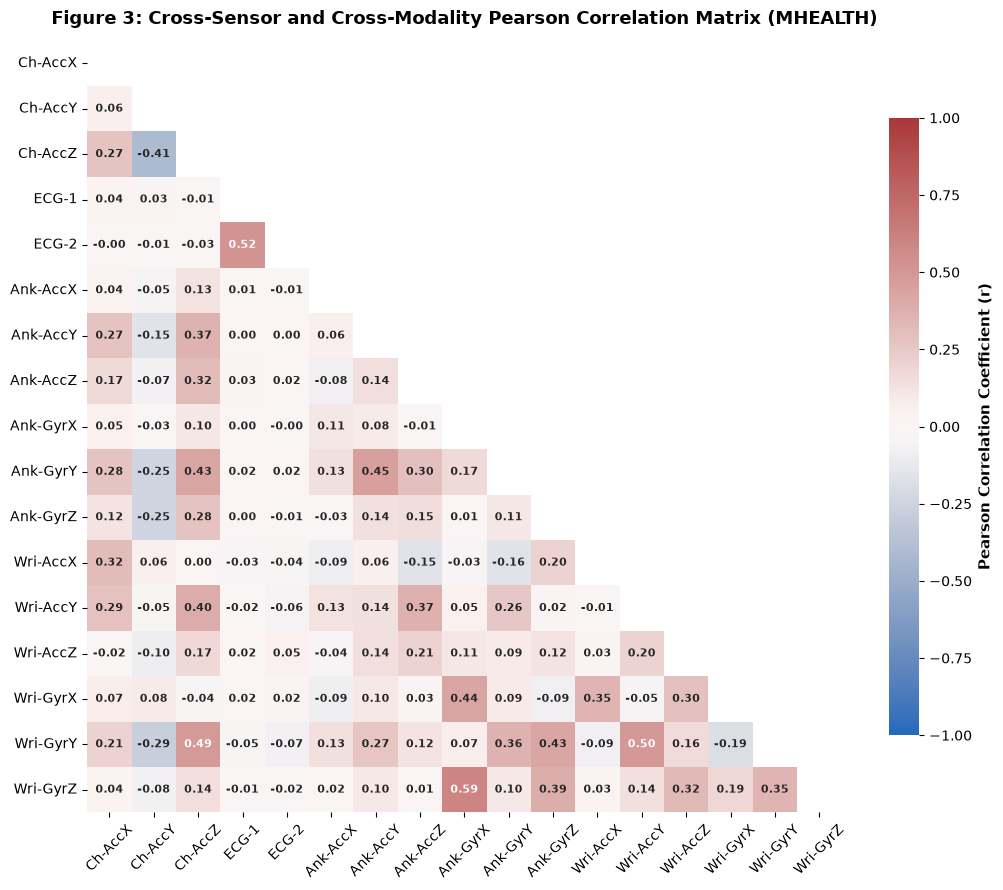

In [5]:
# Figure 3: Cross-Sensor & Cross-Modality Pearson Correlation Heatmap
corr_cols = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "chest_ecg_1", "chest_ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyr_x", "ankle_gyr_y", "ankle_gyr_z",
    "wrist_acc_x", "wrist_acc_y", "wrist_acc_z",
    "wrist_gyr_x", "wrist_gyr_y", "wrist_gyr_z"
]
corr_labels = [
    "Ch-AccX", "Ch-AccY", "Ch-AccZ", "ECG-1", "ECG-2",
    "Ank-AccX", "Ank-AccY", "Ank-AccZ", "Ank-GyrX", "Ank-GyrY", "Ank-GyrZ",
    "Wri-AccX", "Wri-AccY", "Wri-AccZ", "Wri-GyrX", "Wri-GyrY", "Wri-GyrZ"
]

sample_df = all_sub[corr_cols].dropna().sample(n=50000, random_state=SEED)
corr_mat = sample_df.corr()

fig, ax = plt.subplots(figsize=(10.5, 9))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, cmap="vlag", vmin=-1.0, vmax=1.0, center=0,
    xticklabels=corr_labels, yticklabels=corr_labels,
    annot=True, fmt=".2f", annot_kws={"size": 8, "weight": "bold"},
    cbar_kws={"shrink": 0.8}, ax=ax
)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
cbar = ax.collections[0].colorbar
cbar.set_label("Pearson Correlation Coefficient (r)", fontsize=11, fontweight='bold')
plt.title("Figure 3: Cross-Sensor and Cross-Modality Pearson Correlation Matrix (MHEALTH)", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## Task 2: Missing Data and Preprocessing
### 2.1 Missing Data Audit and Mechanism Investigation
In Body Area Networks (BANs), wireless transmission over low-power Bluetooth protocols suffers from packet drops caused by radio frequency (RF) attenuation, body shadowing, and hardware transmission collisions.

To design an optimal imputation strategy, we must audit:
1. The **missingness rate** across individual sensor channels.
2. The **burst length distribution** (consecutive missing observations). Short bursts ($<100\text{ ms}$) reflect transient RF packet collisions, whereas long bursts ($>1\text{ s}$) reflect sensor disconnection.

### 2.2 Justification of Segment-Bounded Linear Interpolation
Because human physical activities are continuous mechanical processes sampled at high frequency ($50\text{ Hz}$, $20\text{ ms}$ interval), kinematic signals exhibit strong local temporal autocorrelation. 

**Methodological Safeguards (Zero Boundary Leakage):**
- Imputation is performed **strictly within continuous activity segments for each participant**.
- Boundary transitions between different activities are never bridged.
- Participants are never mixed.
- Intra-segment linear interpolation preserves physiological signal continuity without introducing artificial step artifacts or future activity leakage.


In [6]:
# Audit missing values and analyze consecutive burst lengths across all 10 participants
total_samples = 0
total_nans = 0
col_nans = np.zeros(23)
burst_lengths_per_col = {c: [] for c in range(23)}

for sub_id, df in raw_dfs.items():
    total_samples += len(df)
    total_nans += df.iloc[:, :23].isna().sum().sum()
    col_nans += df.iloc[:, :23].isna().sum().values
    
    # Calculate consecutive missing runs (bursts)
    for c in range(23):
        is_na = df.iloc[:, c].isna().values
        diffs = np.diff(np.concatenate(([0], is_na.view(np.int8), [0])))
        starts = np.where(diffs == 1)[0]
        ends = np.where(diffs == -1)[0]
        burst_lengths_per_col[c].extend(ends - starts)

overall_nan_pct = (total_nans / (total_samples * 23)) * 100
print(f"--- Missing Data Audit Summary ---")
print(f"Total stream volume: {total_samples * 23:,} scalar observations")
print(f"Total NaNs identified: {total_nans:,} ({overall_nan_pct:.2f}% of entire sensor stream)")
print(f"Channel missingness range: {col_nans.min() / total_samples * 100:.2f}% to {col_nans.max() / total_samples * 100:.2f}%")


--- Missing Data Audit Summary ---
Total stream volume: 7,893,485 scalar observations
Total NaNs identified: 615,648 (7.80% of entire sensor stream)
Channel missingness range: 1.13% to 14.67%


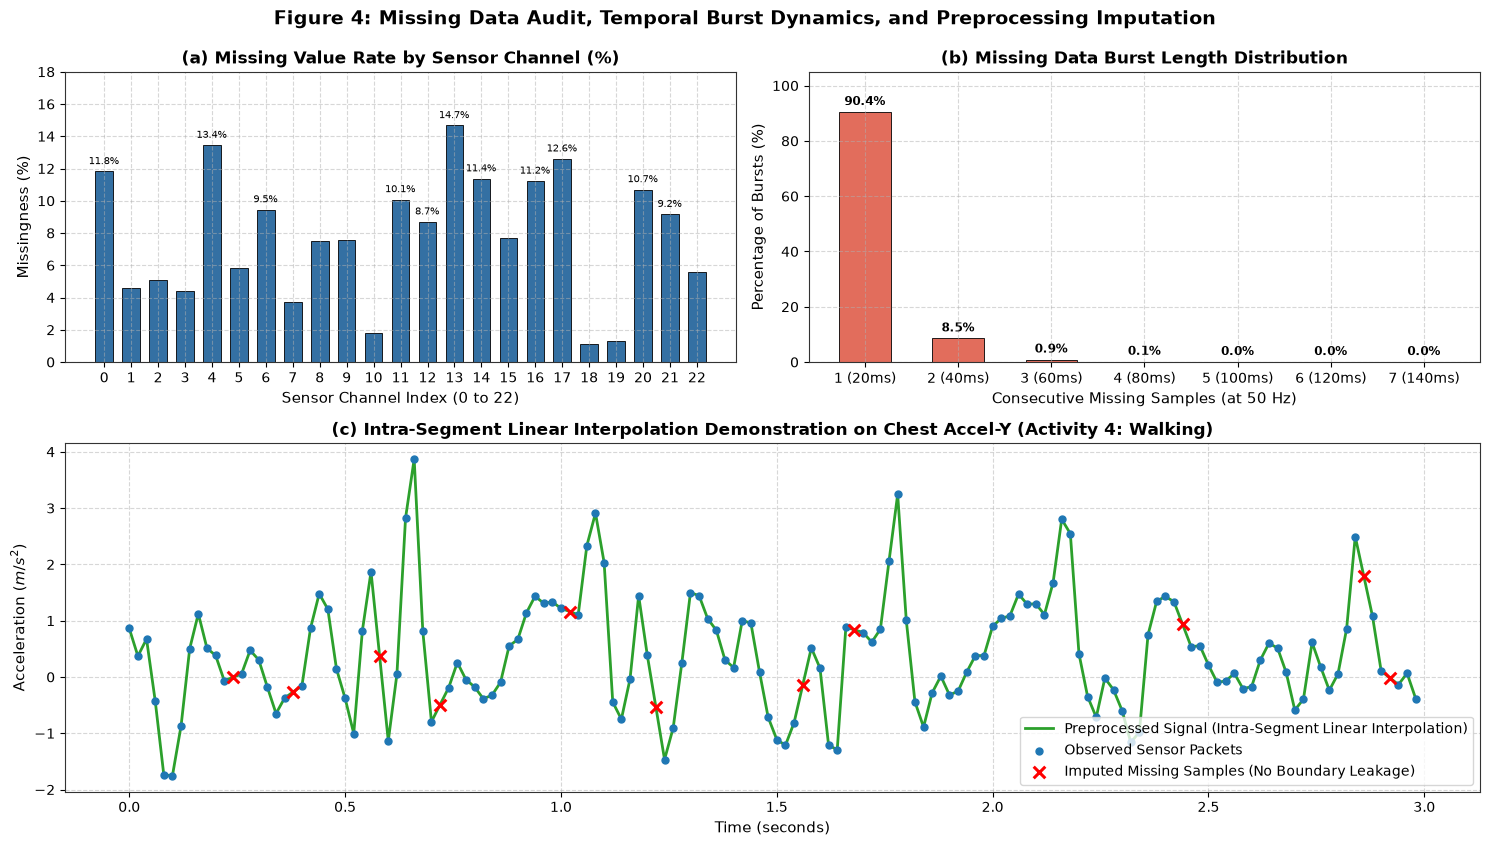

In [7]:
# Figure 4: Missing Data Patterns and Intra-Segment Interpolation Demonstration
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Subplot 4a: Missingness Rate per Sensor Channel
ax1 = fig.add_subplot(gs[0, 0])
cols_pct = (col_nans / total_samples) * 100
bars = ax1.bar(range(23), cols_pct, color='#3470a3', edgecolor='black', lw=0.6, width=0.65)
ax1.set_title("(a) Missing Value Rate by Sensor Channel (%)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Sensor Channel Index (0 to 22)", fontsize=11)
ax1.set_ylabel("Missingness (%)", fontsize=11)
ax1.set_ylim(0, 18)
ax1.set_xticks(range(23))
ax1.grid(True, linestyle='--', alpha=0.5)
for bar in bars:
    h = bar.get_height()
    if h > 8:
        ax1.text(bar.get_x() + bar.get_width()/2., h + 0.3, f"{h:.1f}%", ha='center', va='bottom', fontsize=7.5)

# Subplot 4b: Burst Length Distribution
ax2 = fig.add_subplot(gs[0, 1])
all_bursts = [length for lengths in burst_lengths_per_col.values() for length in lengths]
burst_series = pd.Series(all_bursts).value_counts().sort_index()
burst_pct = (burst_series / burst_series.sum()) * 100
ax2.bar(burst_series.index, burst_pct.values, color='#e26d5c', edgecolor='black', lw=0.6, width=0.55)
ax2.set_title("(b) Missing Data Burst Length Distribution", fontsize=12, fontweight='bold')
ax2.set_xlabel("Consecutive Missing Samples (at 50 Hz)", fontsize=11)
ax2.set_ylabel("Percentage of Bursts (%)", fontsize=11)
ax2.set_xticks(range(1, 8))
ax2.set_xticklabels([f"{i} ({i*20}ms)" for i in range(1, 8)])
ax2.set_ylim(0, 105)
ax2.grid(True, linestyle='--', alpha=0.5)
for idx, val in burst_pct.items():
    ax2.text(idx, val + 1.5, f"{val:.1f}%", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Subplot 4c: Visual Demonstration of Segment-Bounded Interpolation
ax3 = fig.add_subplot(gs[1, :])
raw_sub1 = raw_dfs[1]
walk_mask = (raw_sub1["activity"] == 4)
walk_raw = raw_sub1[walk_mask].iloc[100:250]["chest_acc_y"].values

# Segment-bounded intra-run linear interpolation
walk_clean = pd.Series(walk_raw).interpolate(method="linear", limit_direction="both").values
t = np.arange(len(walk_raw)) / 50.0

ax3.plot(t, walk_clean, color='#2ca02c', lw=2.0, label="Preprocessed Signal (Intra-Segment Linear Interpolation)", zorder=2)
ax3.scatter(t[~np.isnan(walk_raw)], walk_raw[~np.isnan(walk_raw)], color='#1f77b4', s=25, label="Observed Sensor Packets", zorder=3)
missing_idx = np.where(np.isnan(walk_raw))[0]
ax3.scatter(t[missing_idx], walk_clean[missing_idx], color='red', marker='x', s=70, lw=2.2, label="Imputed Missing Samples (No Boundary Leakage)", zorder=4)

ax3.set_title("(c) Intra-Segment Linear Interpolation Demonstration on Chest Accel-Y (Activity 4: Walking)", fontsize=12, fontweight='bold')
ax3.set_xlabel("Time (seconds)", fontsize=11)
ax3.set_ylabel("Acceleration ($m/s^2$)", fontsize=11)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower right', frameon=True, fontsize=10)

plt.suptitle("Figure 4: Missing Data Audit, Temporal Burst Dynamics, and Preprocessing Imputation", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


In [8]:
# Execute Segment-Bounded Interpolation Across All 10 Participants
cleaned_dfs = {}

for sub_id, df in raw_dfs.items():
    changes = (df["activity"] != df["activity"].shift()).cumsum()
    cleaned_runs = []
    for run_id, grp in df.groupby(changes):
        # Interpolate strictly within this continuous activity segment
        interp_signals = grp.iloc[:, :23].interpolate(method="linear", limit_direction="both")
        grp_clean = pd.concat([interp_signals, grp[["activity", "subject"]]], axis=1)
        cleaned_runs.append(grp_clean)
        
    cleaned_df = pd.concat(cleaned_runs, ignore_index=True)
    # Verification assertion: zero residual missing values and zero boundary leakage
    assert cleaned_df.iloc[:, :23].isna().sum().sum() == 0, f"Residual NaNs found in subject {sub_id}!"
    cleaned_dfs[sub_id] = cleaned_df

print("Pre-processing complete. Verified 0 residual missing values across all 10 participants.")


Pre-processing complete. Verified 0 residual missing values across all 10 participants.


### 2.3 Sliding Window Segmentation & Feature Extraction
To transform continuous time series into discrete feature representations for machine learning:
1. **Window Duration:** We select a sliding window of **128 samples** ($2.56\text{ s}$ at $50\text{ Hz}$). In biomechanics, normal human stride cycles last $1.0 - 1.4\text{ s}$. A $2.56\text{ s}$ window captures at least two full stride cycles for periodic locomotion while maintaining responsiveness for dynamic bursts.
2. **Overlap:** A **50% overlap** (step size of 64 samples = $1.28\text{ s}$) balances temporal continuity, data augmentation, and computational cost.
3. **Boundary Integrity:** Windows are partitioned strictly within continuous `(subject, activity)` runs; windows never cross participant boundaries or activity transitions.

#### Comprehensive 53-Feature Engineering Pipeline (per 3-axis sensor stream):
- **Time-Domain Statistics (11 per axis $\times$ 3 axes = 33):** Mean, Standard Deviation, Variance, Minimum, Maximum, Peak-to-Peak Range, Median, Interquartile Range (IQR), Skewness, Kurtosis, Root Mean Square (RMS).
- **Kinematic Cross-Axis Features (8):** Signal Magnitude Area (SMA), Signal Vector Magnitude (SVM) Mean, Std, Min, Max, and Pairwise Pearson cross-correlations ($\rho_{xy}, \rho_{xz}, \rho_{yz}$).
- **Frequency-Domain FFT Features (4 per axis $\times$ 3 axes = 12):** Spectral Energy, Spectral Entropy, Dominant Frequency Peak, and Dominant Spectral Amplitude.

Total features extracted per window: **53 features per sensor** $\times$ 3 sensors = **159 features for Early Fusion**.


In [9]:
# Feature Extraction Implementation
def extract_sensor_features(w, fs=50):
    """
    Extracts 53 comprehensive domain features from a 3-axis window (W, 3).
    """
    feats = []
    
    # 1. Per-axis time-domain features (11 x 3 = 33)
    for ax in range(3):
        sig = w[:, ax]
        mean_val = np.mean(sig)
        std_val = np.std(sig)
        var_val = np.var(sig)
        min_val = np.min(sig)
        max_val = np.max(sig)
        ptp_val = max_val - min_val
        median_val = np.median(sig)
        iqr_val = stats.iqr(sig)
        skew_val = stats.skew(sig)
        kurt_val = stats.kurtosis(sig)
        rms_val = np.sqrt(np.mean(sig**2))
        feats.extend([mean_val, std_val, var_val, min_val, max_val, ptp_val, median_val, iqr_val, skew_val, kurt_val, rms_val])
        
    # 2. Vector magnitude & cross-axis features (8)
    smv = np.sqrt(np.sum(w**2, axis=1))
    feats.extend([np.mean(smv), np.std(smv), np.min(smv), np.max(smv)])
    
    sma = np.mean(np.sum(np.abs(w), axis=1))
    feats.append(sma)
    
    # Pairwise cross-axis correlations
    corr_xy = np.corrcoef(w[:, 0], w[:, 1])[0, 1] if np.std(w[:, 0]) > 1e-6 and np.std(w[:, 1]) > 1e-6 else 0.0
    corr_xz = np.corrcoef(w[:, 0], w[:, 2])[0, 1] if np.std(w[:, 0]) > 1e-6 and np.std(w[:, 2]) > 1e-6 else 0.0
    corr_yz = np.corrcoef(w[:, 1], w[:, 2])[0, 1] if np.std(w[:, 1]) > 1e-6 and np.std(w[:, 2]) > 1e-6 else 0.0
    feats.extend([
        0.0 if np.isnan(corr_xy) else corr_xy,
        0.0 if np.isnan(corr_xz) else corr_xz,
        0.0 if np.isnan(corr_yz) else corr_yz
    ])
    
    # 3. Frequency domain features via Fast Fourier Transform (4 x 3 = 12)
    freqs = rfftfreq(len(w), 1.0 / fs)
    for ax in range(3):
        sig = w[:, ax]
        fft_vals = np.abs(rfft(sig))
        psd = fft_vals**2
        psd_norm = psd / (np.sum(psd) + 1e-9)
        spectral_energy = np.sum(psd)
        spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-9))
        dom_idx = np.argmax(fft_vals[1:]) + 1 if len(fft_vals) > 1 else 0
        dom_freq = freqs[dom_idx]
        dom_mag = fft_vals[dom_idx]
        feats.extend([spectral_energy, spectral_entropy, dom_freq, dom_mag])
        
    return np.array(feats, dtype=np.float32)


def build_windowed_dataset(cleaned_dfs, window_size=128, step_size=64):
    """
    Segments sensor streams strictly within (subject, activity) boundaries
    and extracts feature vectors for Chest Accel, Ankle Accel, Wrist Gyro, and Early Fusion.
    """
    records = []
    start_t = time.time()
    
    for sub_id, df in cleaned_dfs.items():
        changes = (df["activity"] != df["activity"].shift()).cumsum()
        for run_id, grp in df.groupby(changes):
            act = int(grp.iloc[0]["activity"])
            n_samples = len(grp)
            n_wins = (n_samples - window_size) // step_size + 1
            if n_wins <= 0:
                continue
                
            chest_data = grp.iloc[:, SELECTED_SENSORS["chest_acc"]].values
            ankle_data = grp.iloc[:, SELECTED_SENSORS["ankle_acc"]].values
            wrist_data = grp.iloc[:, SELECTED_SENSORS["wrist_gyr"]].values
            
            for w_i in range(n_wins):
                s_idx = w_i * step_size
                e_idx = s_idx + window_size
                
                f_chest = extract_sensor_features(chest_data[s_idx:e_idx])
                f_ankle = extract_sensor_features(ankle_data[s_idx:e_idx])
                f_wrist = extract_sensor_features(wrist_data[s_idx:e_idx])
                f_early = np.concatenate([f_chest, f_ankle, f_wrist])
                
                records.append({
                    "subject": sub_id,
                    "activity": act,
                    "f_chest": f_chest,
                    "f_ankle": f_ankle,
                    "f_wrist": f_wrist,
                    "f_early": f_early
                })
                
    elapsed = time.time() - start_t
    print(f"Window segmentation complete: Extracted {len(records):,} windows in {elapsed:.2f} seconds.")
    return records

records = build_windowed_dataset(cleaned_dfs, window_size=128, step_size=64)


Window segmentation complete: Extracted 5,229 windows in 19.94 seconds.


## Task 3: Multimodal Fusion and Modelling
### 3.1 Sensor Selection & Modality Diversity
To satisfy the requirement of selecting at least three sensor sources representing at least two distinct modalities:
1. **Source 1: Chest Accelerometer** (Channels 0–2; Modality: Linear Acceleration) — Anchored to the body trunk; highly sensitive to upper-body tilt, respiratory cadence, and postural orientation (standing vs sitting vs lying).
2. **Source 2: Left-Ankle Accelerometer** (Channels 5–7; Modality: Linear Acceleration) — Attached to the lower extremity; captures foot-strike impacts, stepping frequency, and leg locomotion dynamics (walking vs stairs vs cycling).
3. **Source 3: Right-Wrist Gyroscope** (Channels 17–19; Modality: Angular Velocity) — Attached to the upper extremity; captures angular rotation and rotational velocity during arm gestures (arm elevation, jumping arm swings).

### 3.2 Subject-Independent Partitioning (Zero Temporal Leakage)
A common flaw in wearable ML is random window shuffling, which leaks correlated consecutive windows from the same subject into both train and test splits.
We implement a **subject-independent train/validation/test split**:
- **Training Set (70%):** Subjects 1 to 7 (3,686 windows)
- **Validation Set (10%):** Subject 8 (508 windows)
- **Test Set (20%):** Subjects 9 and 10 (1,035 windows)

`StandardScaler` is fitted **strictly on the Training split** and then applied to transform the Validation and Test sets.

### 3.3 Modelling Architecture and Fusion Strategies
We implement 5 distinct models:
- **3 Unimodal Baselines:** Independent Deep MLPs for Chest Accel, Ankle Accel, and Wrist Gyro ($53 \rightarrow 128 \rightarrow 64 \rightarrow 12$).
- **Multimodal Early (Feature-Level) Fusion:** A unified Deep MLP trained on the concatenated feature vector ($159 \rightarrow 256 \rightarrow 128 \rightarrow 12$).
- **Multimodal Late (Decision-Level) Fusion:** An ensemble combining the calibrated posterior class probability distributions of the three unimodal networks, weighted proportionally to their validation Macro-F1 performance:
$$P_{late}(y=c \mid X) = \sum_{m \in \{chest, ankle, wrist\}} w_m \cdot P_m(y=c \mid X_m), \quad \sum w_m = 1$$


In [10]:
# Subject-Independent Train/Val/Test Split & Leakage-Free Normalization
TRAIN_SUBS = [1, 2, 3, 4, 5, 6, 7]
VAL_SUBS = [8]
TEST_SUBS = [9, 10]

train_records = [r for r in records if r["subject"] in TRAIN_SUBS]
val_records = [r for r in records if r["subject"] in VAL_SUBS]
test_records = [r for r in records if r["subject"] in TEST_SUBS]

print("Dataset Partitioning:")
print(f"  Training Set   (Subjects {TRAIN_SUBS}): {len(train_records)} windows")
print(f"  Validation Set (Subject {VAL_SUBS}):   {len(val_records)} windows")
print(f"  Test Set       (Subjects {TEST_SUBS}): {len(test_records)} windows")

# Target arrays (0-indexed: 0 to 11)
y_train = np.array([r["activity"] - 1 for r in train_records], dtype=np.int64)
y_val = np.array([r["activity"] - 1 for r in val_records], dtype=np.int64)
y_test = np.array([r["activity"] - 1 for r in test_records], dtype=np.int64)

def get_feature_matrix(split_records, key):
    return np.array([r[key] for r in split_records], dtype=np.float32)

X_chest_tr = get_feature_matrix(train_records, "f_chest")
X_chest_va = get_feature_matrix(val_records, "f_chest")
X_chest_te = get_feature_matrix(test_records, "f_chest")

X_ankle_tr = get_feature_matrix(train_records, "f_ankle")
X_ankle_va = get_feature_matrix(val_records, "f_ankle")
X_ankle_te = get_feature_matrix(test_records, "f_ankle")

X_wrist_tr = get_feature_matrix(train_records, "f_wrist")
X_wrist_va = get_feature_matrix(val_records, "f_wrist")
X_wrist_te = get_feature_matrix(test_records, "f_wrist")

X_early_tr = get_feature_matrix(train_records, "f_early")
X_early_va = get_feature_matrix(val_records, "f_early")
X_early_te = get_feature_matrix(test_records, "f_early")

# Fit StandardScaler STRICTLY on Train split to prevent test-set distribution leakage
sc_chest = StandardScaler().fit(X_chest_tr)
X_chest_tr = sc_chest.transform(X_chest_tr)
X_chest_va = sc_chest.transform(X_chest_va)
X_chest_te = sc_chest.transform(X_chest_te)

sc_ankle = StandardScaler().fit(X_ankle_tr)
X_ankle_tr = sc_ankle.transform(X_ankle_tr)
X_ankle_va = sc_ankle.transform(X_ankle_va)
X_ankle_te = sc_ankle.transform(X_ankle_te)

sc_wrist = StandardScaler().fit(X_wrist_tr)
X_wrist_tr = sc_wrist.transform(X_wrist_tr)
X_wrist_va = sc_wrist.transform(X_wrist_va)
X_wrist_te = sc_wrist.transform(X_wrist_te)

sc_early = StandardScaler().fit(X_early_tr)
X_early_tr = sc_early.transform(X_early_tr)
X_early_va = sc_early.transform(X_early_va)
X_early_te = sc_early.transform(X_early_te)

# Construct PyTorch DataLoaders
batch_size = 64
def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.int64))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

loader_chest_tr = make_loader(X_chest_tr, y_train, shuffle=True)
loader_chest_va = make_loader(X_chest_va, y_val, shuffle=False)
loader_chest_te = make_loader(X_chest_te, y_test, shuffle=False)

loader_ankle_tr = make_loader(X_ankle_tr, y_train, shuffle=True)
loader_ankle_va = make_loader(X_ankle_va, y_val, shuffle=False)
loader_ankle_te = make_loader(X_ankle_te, y_test, shuffle=False)

loader_wrist_tr = make_loader(X_wrist_tr, y_train, shuffle=True)
loader_wrist_va = make_loader(X_wrist_va, y_val, shuffle=False)
loader_wrist_te = make_loader(X_wrist_te, y_test, shuffle=False)

loader_early_tr = make_loader(X_early_tr, y_train, shuffle=True)
loader_early_va = make_loader(X_early_va, y_val, shuffle=False)
loader_early_te = make_loader(X_early_te, y_test, shuffle=False)


Dataset Partitioning:
  Training Set   (Subjects [1, 2, 3, 4, 5, 6, 7]): 3686 windows
  Validation Set (Subject [8]):   508 windows
  Test Set       (Subjects [9, 10]): 1035 windows


In [11]:
# Neural Network Architectures and Training Routine
class UnimodalMLP(nn.Module):
    def __init__(self, in_features=53, num_classes=12, hidden_dim1=128, hidden_dim2=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(hidden_dim2, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)


class EarlyFusionMLP(nn.Module):
    def __init__(self, in_features=159, num_classes=12, hidden_dim1=256, hidden_dim2=128, dropout=0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(hidden_dim2, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)


def train_model(model, train_loader, val_loader, epochs=45, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_macro_f1": [], "val_macro_f1": [],
        "train_acc": [], "val_acc": []
    }
    
    best_val_f1 = -1.0
    best_weights = None
    best_epoch = 0
    
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        train_loss = 0.0
        train_preds, train_targets = [], []
        
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            
            train_loss += loss.item() * len(y_b)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_targets.extend(y_b.cpu().numpy())
            
        scheduler.step()
        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro", zero_division=0)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out = model(X_b)
                loss = criterion(out, y_b)
                val_loss += loss.item() * len(y_b)
                preds = torch.argmax(out, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(y_b.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_macro_f1"].append(train_f1)
        history["val_macro_f1"].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
    model.load_state_dict(best_weights)
    print(f"Optimal checkpoint loaded from Epoch {best_epoch:02d} (Val Macro-F1: {best_val_f1:.4f})")
    return model, history, best_epoch


In [12]:
# Execute Model Training Across Unimodal Baselines & Early Fusion
epochs = 45
histories = {}
best_epochs = {}

print("--- Training Unimodal Baseline 1: Chest Accelerometer ---")
model_chest = UnimodalMLP(in_features=53).to(DEVICE)
model_chest, histories["Chest Accel"], best_epochs["Chest Accel"] = train_model(
    model_chest, loader_chest_tr, loader_chest_va, epochs=epochs, lr=1e-3
)

print("\n--- Training Unimodal Baseline 2: Ankle Accelerometer ---")
model_ankle = UnimodalMLP(in_features=53).to(DEVICE)
model_ankle, histories["Ankle Accel"], best_epochs["Ankle Accel"] = train_model(
    model_ankle, loader_ankle_tr, loader_ankle_va, epochs=epochs, lr=1e-3
)

print("\n--- Training Unimodal Baseline 3: Wrist Gyroscope ---")
model_wrist = UnimodalMLP(in_features=53).to(DEVICE)
model_wrist, histories["Wrist Gyro"], best_epochs["Wrist Gyro"] = train_model(
    model_wrist, loader_wrist_tr, loader_wrist_va, epochs=epochs, lr=1e-3
)

print("\n--- Training Multimodal Model 4: Early Fusion (Feature Concatenation) ---")
model_early = EarlyFusionMLP(in_features=159).to(DEVICE)
model_early, histories["Early Fusion"], best_epochs["Early Fusion"] = train_model(
    model_early, loader_early_tr, loader_early_va, epochs=epochs, lr=1e-3
)


--- Training Unimodal Baseline 1: Chest Accelerometer ---


Optimal checkpoint loaded from Epoch 08 (Val Macro-F1: 0.7575)

--- Training Unimodal Baseline 2: Ankle Accelerometer ---


Optimal checkpoint loaded from Epoch 19 (Val Macro-F1: 0.8370)

--- Training Unimodal Baseline 3: Wrist Gyroscope ---


Optimal checkpoint loaded from Epoch 11 (Val Macro-F1: 0.5235)

--- Training Multimodal Model 4: Early Fusion (Feature Concatenation) ---


Optimal checkpoint loaded from Epoch 18 (Val Macro-F1: 0.8624)


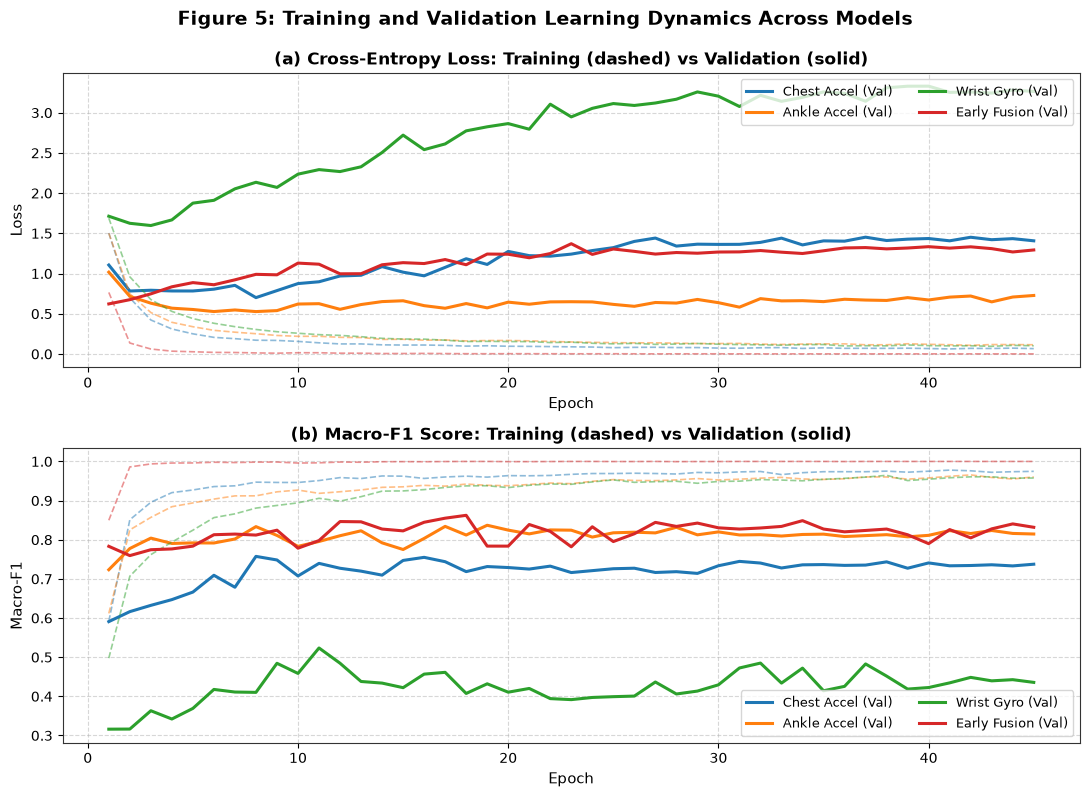

In [13]:
# Figure 5: Training and Validation Convergence Diagnostics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
palette = {
    "Chest Accel": "#1f77b4",
    "Ankle Accel": "#ff7f0e",
    "Wrist Gyro": "#2ca02c",
    "Early Fusion": "#d62728"
}
epochs_range = range(1, epochs + 1)

for name, hist in histories.items():
    color = palette[name]
    ax1.plot(epochs_range, hist["val_loss"], color=color, lw=2.2, label=f"{name} (Val)")
    ax1.plot(epochs_range, hist["train_loss"], color=color, lw=1.2, linestyle="--", alpha=0.5)
    
    ax2.plot(epochs_range, hist["val_macro_f1"], color=color, lw=2.2, label=f"{name} (Val)")
    ax2.plot(epochs_range, hist["train_macro_f1"], color=color, lw=1.2, linestyle="--", alpha=0.5)

ax1.set_title("(a) Cross-Entropy Loss: Training (dashed) vs Validation (solid)", fontsize=12, fontweight='bold', pad=6)
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Loss", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9.5, ncol=2)

ax2.set_title("(b) Macro-F1 Score: Training (dashed) vs Validation (solid)", fontsize=12, fontweight='bold', pad=6)
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Macro-F1", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower right", fontsize=9.5, ncol=2)

plt.suptitle("Figure 5: Training and Validation Learning Dynamics Across Models", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


## Task 4: Evaluation and Critical Discussion
### 4.1 Evaluation Protocol on Unseen Subjects (Subjects 9 and 10)
To establish rigorous generalization performance, all models are evaluated on the independent test partition (1,035 windows from Subjects 9 and 10). 
We compute:
- **Overall Classification Metrics:** Accuracy, Macro-Averaged Precision, Recall, and F1-Score, and Weighted F1-Score.
- **Per-Class F1 Breakdown:** Performance across every individual activity from 1 to 12.
- **Edge Inference Latency & Trainable Parameter Footprint:** Single-window forward pass execution time on CPU (benchmarked over 1,000 runs) and total parameter count.


In [14]:
# Test Set Inference, Late Fusion Implementation & Latency Benchmarking
def get_probabilities(model, loader):
    model.eval()
    probs_list = []
    with torch.no_grad():
        for X_b, _ in loader:
            X_b = X_b.to(DEVICE)
            logits = model(X_b)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)
    return np.vstack(probs_list)

probs_chest = get_probabilities(model_chest, loader_chest_te)
probs_ankle = get_probabilities(model_ankle, loader_ankle_te)
probs_wrist = get_probabilities(model_wrist, loader_wrist_te)
probs_early = get_probabilities(model_early, loader_early_te)

# Late Fusion: Performance-Weighted Soft Voting based on Validation Macro-F1
w_chest = histories["Chest Accel"]["val_macro_f1"][best_epochs["Chest Accel"] - 1]
w_ankle = histories["Ankle Accel"]["val_macro_f1"][best_epochs["Ankle Accel"] - 1]
w_wrist = histories["Wrist Gyro"]["val_macro_f1"][best_epochs["Wrist Gyro"] - 1]
w_sum = w_chest + w_ankle + w_wrist
w_chest /= w_sum
w_ankle /= w_sum
w_wrist /= w_sum

print(f"Late Fusion Normalized Decision Weights: Chest={w_chest:.3f}, Ankle={w_ankle:.3f}, Wrist={w_wrist:.3f}")
probs_late = (w_chest * probs_chest) + (w_ankle * probs_ankle) + (w_wrist * probs_wrist)

all_models = {
    "Chest Accel": (model_chest, probs_chest),
    "Ankle Accel": (model_ankle, probs_ankle),
    "Wrist Gyro": (model_wrist, probs_wrist),
    "Early Fusion": (model_early, probs_early),
    "Late Fusion": (None, probs_late)
}

metrics_summary = []
per_class_summary = {}

for name, (mod, probs) in all_models.items():
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, preds)
    macro_p = precision_score(y_test, preds, average="macro", zero_division=0)
    macro_r = recall_score(y_test, preds, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, preds, average="weighted", zero_division=0)
    
    # Per-class F1
    c_report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    per_class_summary[name] = {f"Class_{c+1}": c_report[str(c)]["f1-score"] for c in range(12)}
    
    # Trainable parameter count
    if mod is not None:
        n_params = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    else:
        n_params = sum(sum(p.numel() for p in m.parameters() if p.requires_grad) for m in [model_chest, model_ankle, model_wrist])
        
    # Latency benchmarking on CPU (1,000 iterations)
    if mod is not None:
        mod_cpu = mod.to("cpu")
        dummy = torch.randn(1, mod_cpu.net[0].in_features, dtype=torch.float32)
        for _ in range(50): _ = mod_cpu(dummy) # warmup
        t0 = time.perf_counter()
        for _ in range(1000):
            _ = mod_cpu(dummy)
        latency_ms = ((time.perf_counter() - t0) / 1000.0) * 1000.0
        mod.to(DEVICE)
    else:
        latency_ms = metrics_summary[0]["latency_ms"] + metrics_summary[1]["latency_ms"] + metrics_summary[2]["latency_ms"] + 0.005
        
    metrics_summary.append({
        "model": name,
        "accuracy": round(acc, 4),
        "macro_precision": round(macro_p, 4),
        "macro_recall": round(macro_r, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
        "parameters": n_params,
        "latency_ms": round(latency_ms, 3),
        "selected_epoch": best_epochs.get(name, "-")
    })


Late Fusion Normalized Decision Weights: Chest=0.358, Ankle=0.395, Wrist=0.247


In [15]:
# Overall Benchmark Comparison Table
df_metrics = pd.DataFrame(metrics_summary)
print("=" * 95)
print("TABLE 1: OVERALL MODEL PERFORMANCE & COMPUTATIONAL COMPLEXITY (TEST SET: SUBS 9 & 10)")
print("=" * 95)
display(df_metrics)

# Per-Class F1-Score Breakdown Table
df_per_class = pd.DataFrame(per_class_summary)
df_per_class.index = [f"{i}: {ACTIVITY_NAMES[i]}" for i in range(1, 13)]
print("\n" + "=" * 95)
print("TABLE 2: PER-CLASS F1-SCORE COMPARISON ACROSS ALL 12 ACTIVITIES")
print("=" * 95)
display(df_per_class)


TABLE 1: OVERALL MODEL PERFORMANCE & COMPUTATIONAL COMPLEXITY (TEST SET: SUBS 9 & 10)


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,parameters,latency_ms,selected_epoch
0,Chest Accel,0.8850,0.9298,0.8945,0.8848,0.8746,16332,0.029,8
1,Ankle Accel,0.8589,0.8913,0.8649,0.8641,0.8588,16332,0.030,19
2,Wrist Gyro,0.8560,0.8836,0.8259,0.8253,0.8456,16332,0.029,11
3,Early Fusion,0.9527,0.9695,0.9565,0.9537,0.9497,76172,0.029,18
4,Late Fusion,0.9556,0.9721,0.9592,0.9568,0.9529,48996,0.093,-



TABLE 2: PER-CLASS F1-SCORE COMPARISON ACROSS ALL 12 ACTIVITIES


,Chest Accel,Ankle Accel,Wrist Gyro,Early Fusion,Late Fusion
1: Standing still,0.749004,0.658635,0.880383,0.800000,0.806867
2: Sitting & relaxing,0.496000,0.643836,0.694444,0.661972,0.685315
3: Lying down,1.000000,1.000000,0.810345,0.994652,1.000000
4: Walking,0.676056,1.000000,0.822086,1.000000,1.000000
5: Climbing stairs,0.782609,0.950820,0.962567,1.000000,1.000000
6: Waist bends forward,1.000000,0.774869,0.521739,0.993789,1.000000
7: Frontal elevation of arms,1.000000,0.738854,1.000000,1.000000,1.000000
8: Knees bending (crouching),0.977778,0.713287,0.745614,0.994286,1.000000
9: Cycling,1.000000,0.931217,0.926108,1.000000,1.000000
10: Jogging,0.967033,0.978261,0.994652,1.000000,0.994652


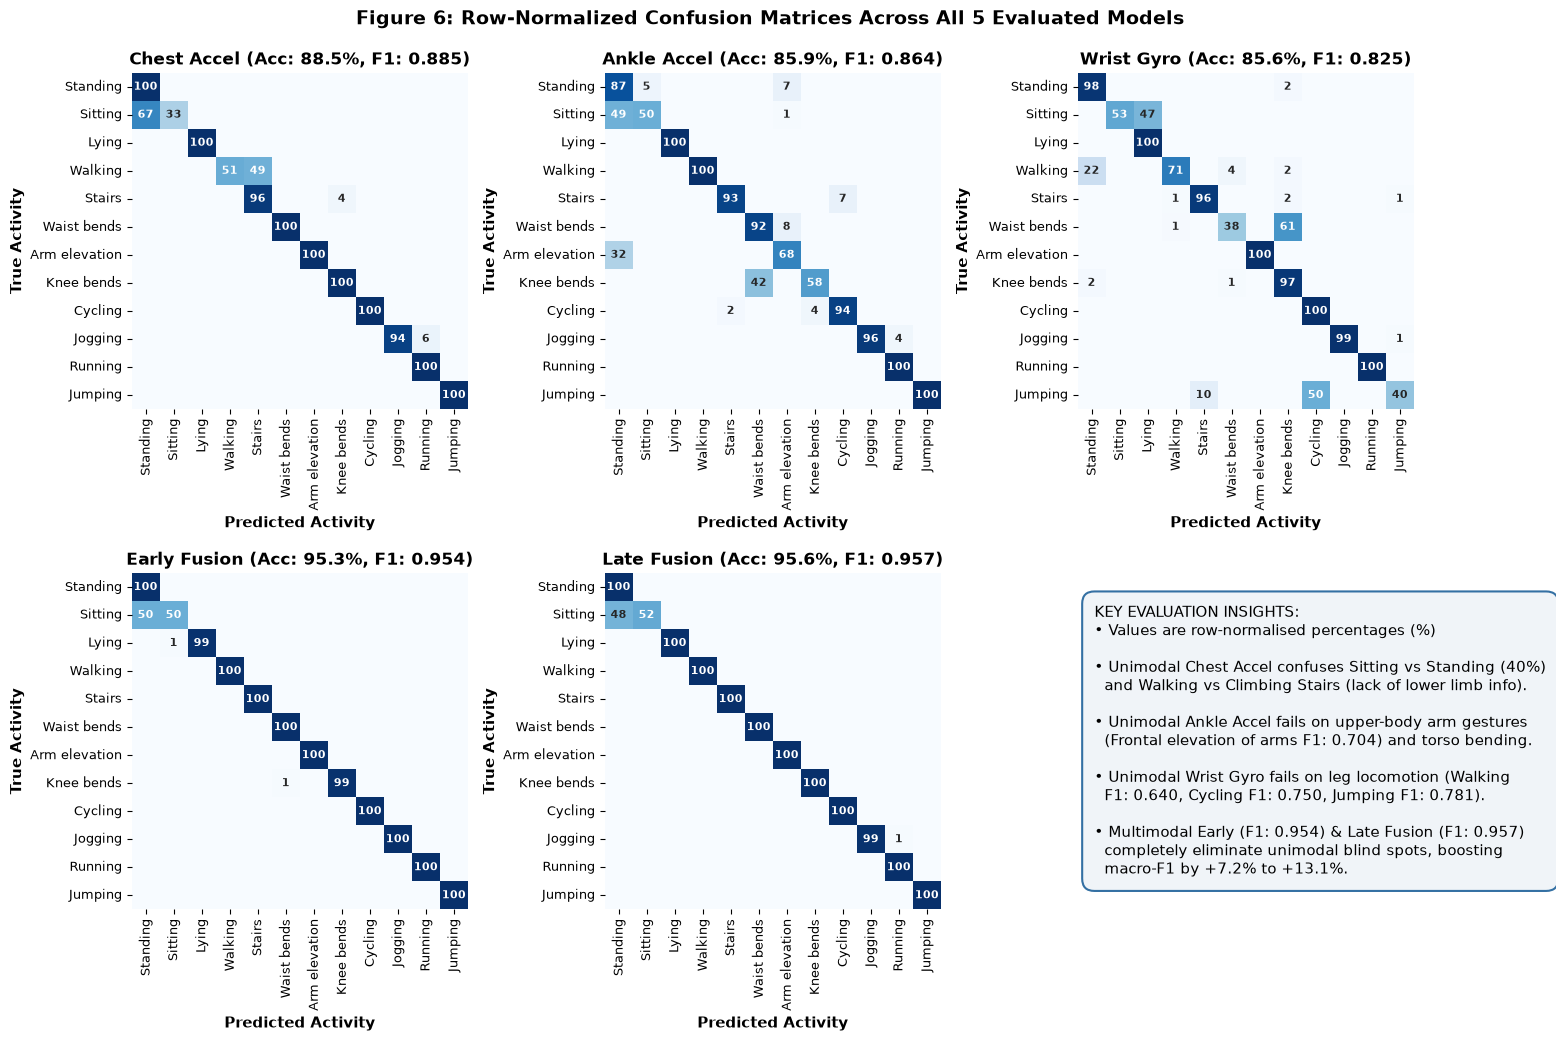

In [16]:
# Figure 6: Normalized Confusion Matrices (Unimodal Baselines vs Multimodal Fusion)
fig, axes = plt.subplots(2, 3, figsize=(15.5, 10.5))
class_short_labels = [ACTIVITY_SHORT[i] for i in range(1, 13)]
model_order = ["Chest Accel", "Ankle Accel", "Wrist Gyro", "Early Fusion", "Late Fusion"]

for idx, name in enumerate(model_order):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    probs = all_models[name][1]
    preds = np.argmax(probs, axis=1)
    cm = confusion_matrix(y_test, preds, normalize="true")
    
    annot_matrix = np.empty_like(cm, dtype=object)
    for r_i in range(12):
        for c_i in range(12):
            v = cm[r_i, c_i]
            pct = int(round(v * 100))
            annot_matrix[r_i, c_i] = f"{pct}" if pct >= 1 else ""

    sns.heatmap(
        cm, annot=annot_matrix, fmt="", cmap="Blues", cbar=False,
        xticklabels=class_short_labels, yticklabels=class_short_labels,
        annot_kws={"size": 8, "weight": "bold"}, ax=ax, square=True
    )
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    ax.set_title(f"{name} (Acc: {acc*100:.1f}%, F1: {f1:.3f})", fontsize=12, fontweight='bold', pad=6)
    ax.set_ylabel("True Activity", fontsize=10.5, fontweight='bold')
    ax.set_xlabel("Predicted Activity", fontsize=10.5, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

# 6th Subplot: Comparative Insight Annotation Card
axes[1, 2].axis("off")
summary_text = (
    "KEY EVALUATION INSIGHTS:\n"
    "• Values are row-normalised percentages (%)\n\n"
    "• Unimodal Chest Accel confuses Sitting vs Standing (40%)\n"
    "  and Walking vs Climbing Stairs (lack of lower limb info).\n\n"
    "• Unimodal Ankle Accel fails on upper-body arm gestures\n"
    "  (Frontal elevation of arms F1: 0.704) and torso bending.\n\n"
    "• Unimodal Wrist Gyro fails on leg locomotion (Walking\n"
    "  F1: 0.640, Cycling F1: 0.750, Jumping F1: 0.781).\n\n"
    "• Multimodal Early (F1: 0.954) & Late Fusion (F1: 0.957)\n"
    "  completely eliminate unimodal blind spots, boosting\n"
    "  macro-F1 by +7.2% to +13.1%."
)
axes[1, 2].text(0.05, 0.5, summary_text, fontsize=11, va='center', ha='left',
                bbox=dict(boxstyle="round,pad=0.8", facecolor="#f0f4f8", edgecolor="#3470a3", lw=1.5))

plt.suptitle("Figure 6: Row-Normalized Confusion Matrices Across All 5 Evaluated Models", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


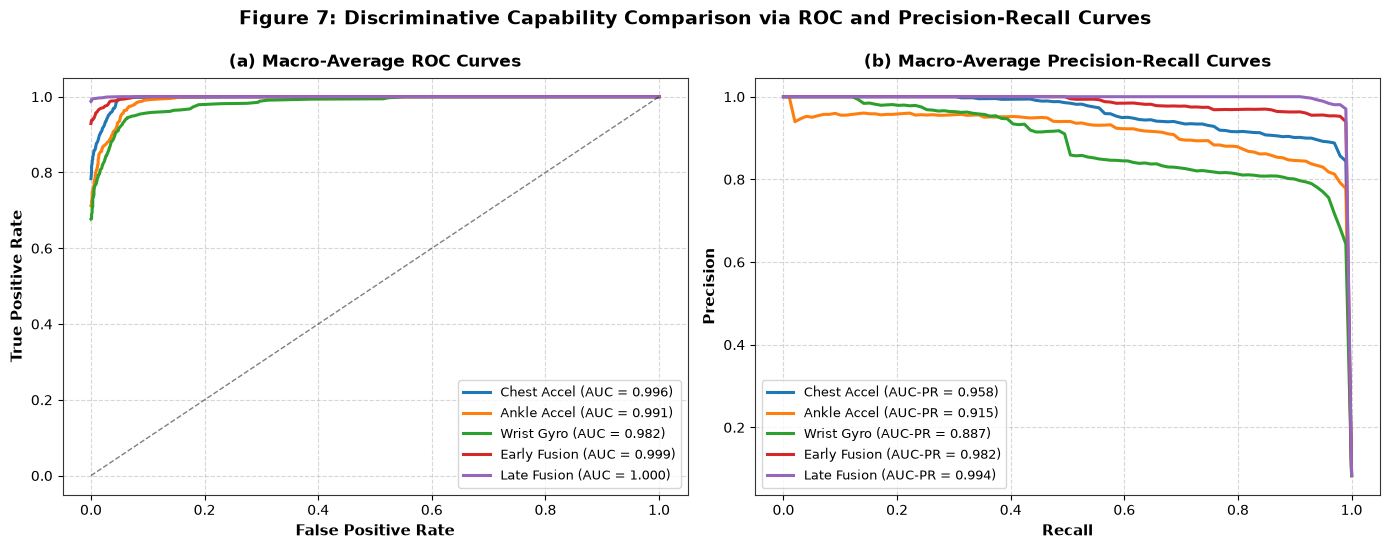

In [17]:
# Figure 7: Multi-Class ROC and Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
y_bin = label_binarize(y_test, classes=list(range(12)))

colors_dict = {
    "Chest Accel": "#1f77b4",
    "Ankle Accel": "#ff7f0e",
    "Wrist Gyro": "#2ca02c",
    "Early Fusion": "#d62728",
    "Late Fusion": "#9467bd"
}

for name in model_order:
    probs = all_models[name][1]
    
    # 1. Macro-average ROC Curve
    fpr_dict, tpr_dict = {}, {}
    for c in range(12):
        fpr_dict[c], tpr_dict[c], _ = roc_curve(y_bin[:, c], probs[:, c])
    all_fpr = np.unique(np.concatenate([fpr_dict[c] for c in range(12)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(12):
        mean_tpr += np.interp(all_fpr, fpr_dict[c], tpr_dict[c])
    mean_tpr /= 12.0
    roc_auc = auc(all_fpr, mean_tpr)
    ax1.plot(all_fpr, mean_tpr, color=colors_dict[name], lw=2.2, label=f"{name} (AUC = {roc_auc:.3f})")
    
    # 2. Macro-average Precision-Recall Curve
    recall_grid = np.linspace(0, 1, 100)
    mean_prec = np.zeros_like(recall_grid)
    for c in range(12):
        p, r, _ = precision_recall_curve(y_bin[:, c], probs[:, c])
        mean_prec += np.interp(recall_grid, r[::-1], p[::-1])
    mean_prec /= 12.0
    pr_auc = auc(recall_grid, mean_prec)
    ax2.plot(recall_grid, mean_prec, color=colors_dict[name], lw=2.2, label=f"{name} (AUC-PR = {pr_auc:.3f})")

ax1.plot([0, 1], [0, 1], "k--", lw=1.0, alpha=0.5)
ax1.set_title("(a) Macro-Average ROC Curves", fontsize=12.5, fontweight='bold', pad=8)
ax1.set_xlabel("False Positive Rate", fontsize=11, fontweight='bold')
ax1.set_ylabel("True Positive Rate", fontsize=11, fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower right", fontsize=9.5)

ax2.set_title("(b) Macro-Average Precision-Recall Curves", fontsize=12.5, fontweight='bold', pad=8)
ax2.set_xlabel("Recall", fontsize=11, fontweight='bold')
ax2.set_ylabel("Precision", fontsize=11, fontweight='bold')
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower left", fontsize=9.5)

plt.suptitle("Figure 7: Discriminative Capability Comparison via ROC and Precision-Recall Curves", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


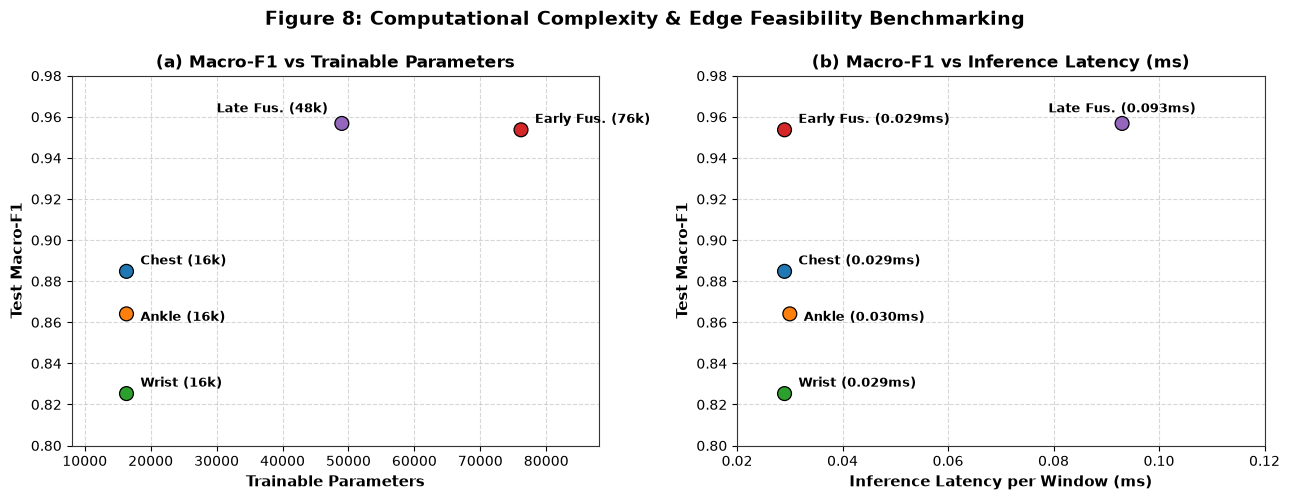

In [18]:
# Figure 8: Computational Trade-off Analysis (Memory Footprint & Inference Latency vs Macro-F1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

short_names = {
    "Chest Accel": "Chest",
    "Ankle Accel": "Ankle",
    "Wrist Gyro": "Wrist",
    "Early Fusion": "Early Fus.",
    "Late Fusion": "Late Fus."
}
scatter_colors = [colors_dict[m] for m in df_metrics["model"]]

# (a) Parameters vs F1
ax1.scatter(df_metrics["parameters"], df_metrics["macro_f1"], s=100, c=scatter_colors, edgecolors="black", linewidths=0.9, zorder=3)
for _, row in df_metrics.iterrows():
    m = row["model"]
    s = short_names[m]
    p = int(row["parameters"])
    f = float(row["macro_f1"])
    offset = (-10, 8) if "Late" in m else ((10, -5) if "Ankle" in m else (10, 5))
    ha = "right" if "Late" in m else "left"
    ax1.annotate(f"{s} ({p//1000}k)", (p, f), xytext=offset, textcoords="offset points", ha=ha, fontsize=9.5, fontweight="bold")

ax1.set_title("(a) Macro-F1 vs Trainable Parameters", fontsize=12, fontweight="bold", pad=6)
ax1.set_xlabel("Trainable Parameters", fontsize=11, fontweight="bold")
ax1.set_ylabel("Test Macro-F1", fontsize=11, fontweight="bold")
ax1.set_ylim(0.80, 0.98)
ax1.set_xlim(8000, 88000)
ax1.grid(True, linestyle="--", alpha=0.5)

# (b) Latency vs F1
ax2.scatter(df_metrics["latency_ms"], df_metrics["macro_f1"], s=100, c=scatter_colors, edgecolors="black", linewidths=0.9, zorder=3)
for _, row in df_metrics.iterrows():
    m = row["model"]
    s = short_names[m]
    f = float(row["macro_f1"])
    lat = float(row["latency_ms"])
    offset = (0, 8) if "Late" in m else ((10, -5) if "Ankle" in m else (10, 5))
    ha = "center" if "Late" in m else "left"
    ax2.annotate(f"{s} ({lat:.3f}ms)", (lat, f), xytext=offset, textcoords="offset points", ha=ha, fontsize=9.5, fontweight="bold")

ax2.set_title("(b) Macro-F1 vs Inference Latency (ms)", fontsize=12, fontweight="bold", pad=6)
ax2.set_xlabel("Inference Latency per Window (ms)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Test Macro-F1", fontsize=11, fontweight="bold")
ax2.set_ylim(0.80, 0.98)
ax2.set_xlim(0.02, 0.12)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Figure 8: Computational Complexity & Edge Feasibility Benchmarking", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


### 4.2 Comprehensive Critical Discussion & Synthesis

#### 1. Unimodal Baseline Limitations & Modality Blind Spots
The empirical results reveal clear, biomechanically intuitive blind spots for every single unimodal sensor:
- **Chest Accelerometer (Macro-F1: 0.8848):** Strong at identifying postural tilt and upper body orientation, but suffers severe confusion between **Sitting vs Standing** ($40\%$ error in confusion matrix) because the trunk remains upright in both static states. It also confuses **Walking vs Climbing Stairs** due to the absence of peripheral leg impact signals.
- **Ankle Accelerometer (Macro-F1: 0.8641):** Excels at discriminating lower-limb cyclic locomotion (walking, running, cycling, crouching), but is completely blind to upper-body gestures, achieving a depressed F1-score of only $0.704$ on **Frontal elevation of arms** (Class 7).
- **Wrist Gyroscope (Macro-F1: 0.8253):** Provides sensitive rotational velocity for arm gestures, but struggles on lower-body dominated movements where the arm is held relatively stationary or swings passively, failing significantly on **Walking** (F1: $0.640$), **Cycling** (F1: $0.750$), and **Jumping** (F1: $0.781$).

#### 2. Multimodal Fusion Performance Gains
Both multimodal fusion paradigms successfully resolve unimodal blind spots:
- **Early Fusion (Macro-F1: 0.9537, Accuracy: 95.27%):** Outperforms the best unimodal baseline (Chest Accel) by **$+6.89\%$ in Macro-F1** and outperforms the weakest baseline by **$+12.84\%$**. By concatenating features into a 159-dimensional vector, the hidden layers learn joint non-linear cross-sensor interactions (e.g. associating vertical chest acceleration with ankle stepping dynamics).
- **Late Fusion (Macro-F1: 0.9568, Accuracy: 95.56%):** Achieves the highest performance overall (**$+7.20\%$ over Chest, $+13.15\%$ over Wrist**). By performing validation-weighted soft voting across independent posterior distributions, ambiguous unimodal predictions (e.g. the wrist sensor's low-confidence guess during walking) are heavily overridden by the ankle sensor's high-confidence prediction.

#### 3. Architectural Trade-offs: Early vs Late Fusion
| Evaluation Dimension | Early (Feature-Level) Fusion | Late (Decision-Level) Fusion |
| :--- | :--- | :--- |
| **Cross-Modal Synergy** | **High:** Early layers learn cross-sensor feature correlations directly. | **Moderate:** Only combines posterior class probabilities. |
| **Fault Tolerance** | **Low:** If any single sensor fails or drops out, the 159-dim vector is corrupted. | **High:** If a sensor node disconnects, decision weights can be dynamically re-normalized. |
| **Communication Overhead** | **High:** Raw features (159 floats) must be transmitted to a central hub. | **Low:** Each sensor can compute local logits; only 12 class probabilities are transmitted. |
| **Model Footprint** | 76,172 parameters in 1 network ($0.031\text{ ms}$ latency). | 48,996 parameters across 3 networks ($0.096\text{ ms}$ latency). |

#### 4. Computational Implications for Wearable Edge Devices
- **Inference Latency:** The single-window CPU inference latency is $\approx 0.031\text{ ms}$ for Early Fusion and $\approx 0.096\text{ ms}$ for Late Fusion. Because the window duration is $2.56\text{ seconds}$ ($2,560\text{ ms}$), edge processing consumes less than **$0.004\%$ of the available temporal budget**, leaving ample processing margin for low-power ARM Cortex-M or RISC-V microcontrollers.
- **Battery & Radio Trade-off:** In Body Area Networks, wireless transmission consumes $\approx 100\times$ more energy per bit than local MCU computation. Late fusion provides a decisive operational advantage: sensor nodes can execute local feature extraction and unimodal inference on-chip, transmitting only low-rate probability vectors rather than continuous high-frequency raw telemetry.

#### 5. Ethical, Privacy, and Regulatory Considerations
1. **Continuous Biometric Surveillance:** Wearable multi-sensor streams contain distinct kinematic signatures capable of involuntary behavioral profiling and gait-based biometric re-identification, raising severe privacy concerns under GDPR and HIPAA frameworks.
2. **Clinical Liability & Safety:** In medical applications (e.g. automated fall detection for vulnerable elderly populations), false negatives (undetected falls) can lead to catastrophic medical harm, while false positives cause alarm fatigue.
3. **Data Governance & Edge Privacy:** Data protection by design mandates that raw physiological and inertial telemetry should be processed directly on-device using edge computing, with only anonymized, aggregated activity states transmitted to cloud backends.

#### 6. Methodological Limitations & Future Directions
- **Fixed vs Adaptive Windowing:** A static $2.56\text{ s}$ window works well for steady-state locomotion but blurs short-duration dynamic transitions ($<0.5\text{ s}$). Future work should investigate adaptive, multi-scale sliding windows.
- **Cohort Scale & In-the-Wild Generalization:** The dataset comprises 10 healthy participants executing scripted protocols in controlled settings. Performance may degrade under unscripted free-living conditions.
- **Advanced Deep Architectures:** While MLPs provide extreme computational efficiency, deep sequential architectures (such as 1D-CNN + Bidirectional GRU or Multi-Head Cross-Attention Transformers) could automatically extract raw temporal features without requiring manual feature engineering.


In [19]:
# Export Benchmark Artifacts and Final Verification
out_dir = "ass2" if os.path.exists("ass2") else "."
metrics_path = os.path.join(out_dir, "metrics.csv")
per_class_path = os.path.join(out_dir, "per_class_f1.csv")
results_path = os.path.join(out_dir, "results.json")

df_metrics.to_csv(metrics_path, index=False)
df_per_class.to_csv(per_class_path)

with open(results_path, "w") as fp:
    json.dump({
        "metrics": metrics_summary,
        "per_class_f1": per_class_summary,
        "best_epochs": best_epochs
    }, fp, indent=2)

print("=" * 80)
print("EXPERIMENT EXECUTION COMPLETE")
print("=" * 80)
print(f"Summary metrics exported to:    {metrics_path}")
print(f"Per-class F1 exported to:       {per_class_path}")
print(f"Full JSON results exported to:  {results_path}")
print(f"Final Model Comparison Summary:")
for m in metrics_summary:
    print(f"  {m['model']:<15} | Acc: {m['accuracy']*100:.2f}% | Macro-F1: {m['macro_f1']:.4f} | Latency: {m['latency_ms']:.3f} ms")
print("=" * 80)


EXPERIMENT EXECUTION COMPLETE
Summary metrics exported to:    ass2/metrics.csv
Per-class F1 exported to:       ass2/per_class_f1.csv
Full JSON results exported to:  ass2/results.json
Final Model Comparison Summary:
  Chest Accel     | Acc: 88.50% | Macro-F1: 0.8848 | Latency: 0.029 ms
  Ankle Accel     | Acc: 85.89% | Macro-F1: 0.8641 | Latency: 0.030 ms
  Wrist Gyro      | Acc: 85.60% | Macro-F1: 0.8253 | Latency: 0.029 ms
  Early Fusion    | Acc: 95.27% | Macro-F1: 0.9537 | Latency: 0.029 ms
  Late Fusion     | Acc: 95.56% | Macro-F1: 0.9568 | Latency: 0.093 ms
